# VLM Visual Agnosia Experiment

**Research Question:** Do VLMs show human-like patterns of object recognition failure under degraded or fragmented visual input, mirroring the dissociations seen in apperceptive vs. associative visual agnosia?

**Hypothesis:** VLMs will pass degraded line drawings (where bottom-up feature matching is possible) but fail Mooney images (which require top-down global form completion before any recognition is possible). This would suggest their visual processing is texture/feature-based rather than genuinely perceptual, consistent with Marjieh et al.'s finding that visual input does not add perceptual structure beyond what language already captures.

## 1. Setup

In [1]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import base64
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

# All Gemini models (gemini-2.5-pro, gemini-3-flash-preview, gemini-3.1-flash-lite-preview)
# return 400 on this endpoint despite being listed at /v1/models.
# Confirmed working vision models:
MODELS = [
    "claude-sonnet-4-5",   # Anthropic
    "gpt-5.4",             # OpenAI
]

print("Setup complete.")
print("Active models:", MODELS)

Setup complete.
Active models: ['claude-sonnet-4-5', 'gpt-5.4']


In [4]:
## 2. Load Stimuli

Found 161 objects matched across all 6 conditions.


condition
degraded_25    161
degraded_50    161
degraded_75    161
degraded_90    161
mooney         161
mooney_inv     161
Name: n_trials, dtype: int64

## 3. Prompting

Simple forced-choice prompt — model names the object in one word or short phrase. Same prompt used across all models and conditions (controls for autoregressive artifact confound).

In [5]:
SYSTEM_PROMPT = "You are participating in an object recognition experiment. Respond with only the name of the object you see — a single word or short noun phrase. Do not describe the image. Do not say you are unsure. Just name the object."

USER_PROMPT = "What object is in this image?"

# Synonym map: label (no underscores) -> list of accepted alternatives
SYNONYMS = {
    "garbage can":    ["trash can", "rubbish bin", "waste bin", "dustbin"],
    "gun":            ["revolver", "pistol", "firearm", "handgun"],
    "kettle":         ["teapot"],
    "pot":            ["saucepan", "cooking pot"],
    "pocketbook":     ["handbag", "purse", "wallet"],
    "wineglass":      ["goblet", "wine glass"],
    "sea horse":      ["seahorse"],
    "roller skate":   ["roller skates"],
    "tennis racket":  ["tennis racquet", "racket", "racquet"],
    "record player":  ["turntable", "gramophone", "phonograph"],
    "jacket":         ["coat", "blazer"],
    "seal":           ["sea lion"],
}


def query_model(model, image_path, system_prompt=SYSTEM_PROMPT, user_prompt=USER_PROMPT):
    """
    Send a single image to a VLM and return its text response.
    """
    image_data = encode_image(image_path)
    ext = os.path.splitext(image_path)[-1].lower().replace(".", "")
    mime = "image/jpeg" if ext in ("jpg", "jpeg") else "image/png"

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{image_data}"}},
                    {"type": "text", "text": user_prompt}
                ]
            }
        ],
        reasoning_effort=None
    )

    return response.choices[0].message.content.strip().lower()


def is_correct(response, true_label):
    """
    Check if the model's response matches the true object label.
    - Normalizes underscores to spaces before comparison
    - Accepts known synonyms
    """
    resp = response.lower().strip()
    label = true_label.lower().replace("_", " ").strip()

    if label in resp:
        return True

    for syn in SYNONYMS.get(label, []):
        if syn.lower() in resp:
            return True

    return False


print("Prompting functions ready.")

Prompting functions ready.


## 4. Run Experiment

In [6]:
def run_experiment(stimuli, models):
    """
    Run all stimuli through all models. Returns a DataFrame of results.
    """
    results = []

    for model in models:
        print(f"\nRunning model: {model}")
        for trial in tqdm(stimuli):
            response = query_model(model, trial["path"])
            correct = is_correct(response, trial["label"])
            results.append({
                "model": model,
                "label": trial["label"],
                "condition": trial["condition"],
                "response": response,
                "correct": correct
            })

    return pd.DataFrame(results)


# Uncomment to run (requires stimuli to be loaded)
stimuli = load_stimuli()
results_df = run_experiment(stimuli, MODELS)
results_df.to_csv("results.csv", index=False)
results_df.head()

Found 161 objects matched across all 6 conditions.

Running model: claude-sonnet-4-5


100%|██████████| 966/966 [23:05<00:00,  1.43s/it]  



Running model: gpt-5.4


100%|██████████| 966/966 [1:47:45<00:00,  6.69s/it]    


,model,label,condition,response,correct
0,claude-sonnet-4-5,frog,mooney,rat,False
1,claude-sonnet-4-5,frog,mooney_inv,polar bear,False
2,claude-sonnet-4-5,frog,degraded_25,frog,True
3,claude-sonnet-4-5,frog,degraded_50,frog,True
4,claude-sonnet-4-5,frog,degraded_75,frog,True


## 5. Analysis & Plots

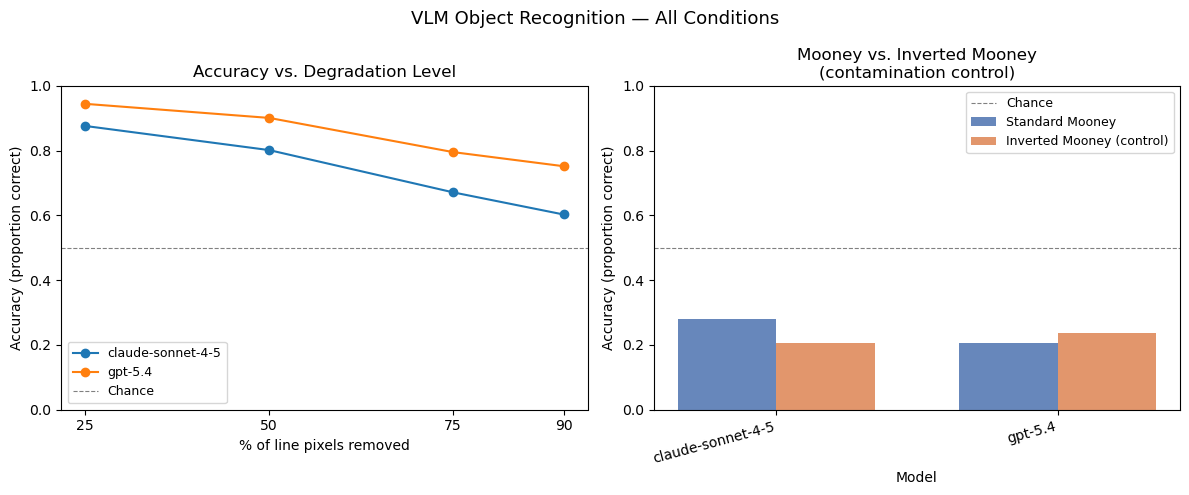

,model,condition,accuracy
0,claude-sonnet-4-5,degraded_25,0.875776
1,claude-sonnet-4-5,degraded_50,0.801242
2,claude-sonnet-4-5,degraded_75,0.670807
3,claude-sonnet-4-5,degraded_90,0.602484
4,claude-sonnet-4-5,mooney,0.279503
5,claude-sonnet-4-5,mooney_inv,0.204969
6,gpt-5.4,degraded_25,0.944099
7,gpt-5.4,degraded_50,0.900621
8,gpt-5.4,degraded_75,0.795031
9,gpt-5.4,degraded_90,0.751553


In [7]:
# Load results
results_df = pd.read_csv("results.csv")

def plot_accuracy(results_df):
    """
    Two-panel figure:
      Left:  accuracy curve across degradation levels (25/50/75%)
      Right: bar chart for Mooney vs. inverted Mooney
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]
    models = summary["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: degradation curve ---
    ax = axes[0]
    degraded_conditions = ["degraded_25", "degraded_50", "degraded_75", "degraded_90"]
    x_vals = [25, 50, 75, 90]
    for model in models:
        y_vals = [
            summary[(summary["model"] == model) & (summary["condition"] == c)]["accuracy"].values[0]
            for c in degraded_conditions
        ]
        ax.plot(x_vals, y_vals, marker="o", label=model.split("/")[-1])
    ax.set_xlabel("% of line pixels removed")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Accuracy vs. Degradation Level")
    ax.set_xticks(x_vals)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
    ax.legend(fontsize=9)

    # --- Right: Mooney vs. inverted Mooney ---
    ax = axes[1]
    mooney_conditions = ["mooney", "mooney_inv"]
    x = np.arange(len(models))
    width = 0.35
    colors = ["#4C72B0", "#DD8452"]
    for i, cond in enumerate(mooney_conditions):
        vals = [
            summary[(summary["model"] == m) & (summary["condition"] == cond)]["accuracy"].values[0]
            for m in models
        ]
        label = "Standard Mooney" if cond == "mooney" else "Inverted Mooney (control)"
        ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.85)
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Mooney vs. Inverted Mooney\n(contamination control)")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
    ax.legend(fontsize=9)

    plt.suptitle("VLM Object Recognition — All Conditions", fontsize=13)
    plt.tight_layout()
    plt.savefig("accuracy_by_condition.png", dpi=150)
    plt.show()
    return summary


plot_accuracy(results_df)


## 6. Human Comparison

Human benchmarks from the literature (used as directional baselines):

- **Mooney images (objects):** ~34% spontaneous recognition (Snodgrass & Corwin, 1988)
- **Degraded line drawings:** ~63% at 25% removal → ~15% at 90% removal (Snodgrass & Corwin, 1988; Koch et al., 1995)

**Limitation:** Human norms were collected using a different degradation method on the same S&V stimuli. The comparison is directional, not exact. Acknowledged in the Open Questions slide.

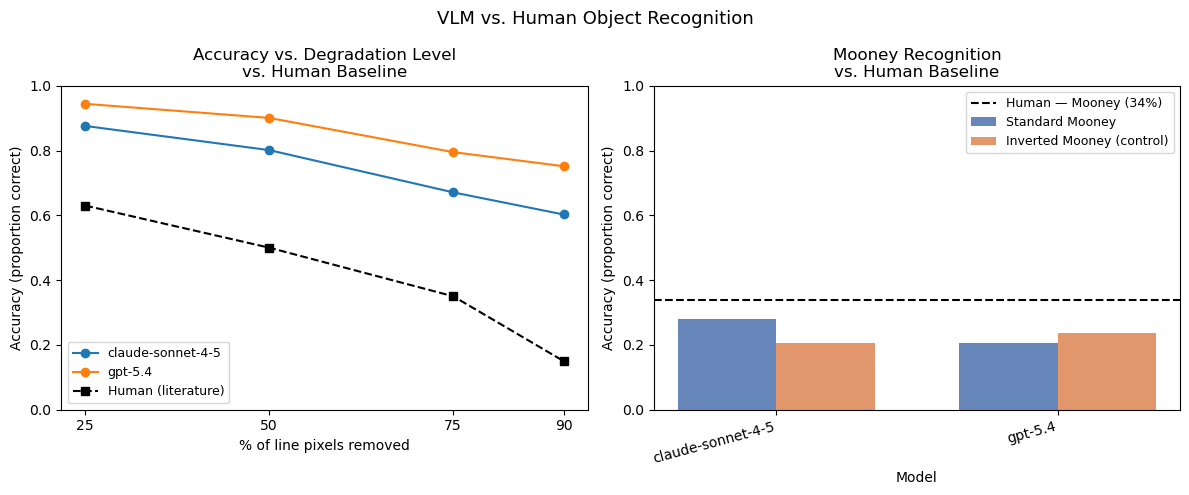

In [8]:
def plot_with_human_baseline(results_df,
                             human_mooney=0.34,
                             human_degraded={25: 0.63, 50: 0.50, 75: 0.35, 90: 0.15}):
    """
    Two-panel figure with human baselines overlaid.

    Human baselines (from Snodgrass & Corwin, 1988; Koch et al., 1995):
      - Mooney objects:         ~34% spontaneous recognition
      - Degraded 75% removed:  ~35% (threshold fragmentation)
      - Degraded 50% removed:  ~50% (interpolated)
      - Degraded 25% removed:  ~63% (easier items, Koch et al.)
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]
    models = summary["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: degradation curve with human baseline ---
    ax = axes[0]
    degraded_conditions = ["degraded_25", "degraded_50", "degraded_75", "degraded_90"]
    x_vals = [25, 50, 75, 90]
    for model in models:
        y_vals = [
            summary[(summary["model"] == model) & (summary["condition"] == c)]["accuracy"].values[0]
            for c in degraded_conditions
        ]
        ax.plot(x_vals, y_vals, marker="o", label=model.split("/")[-1])
    human_y = [human_degraded[x] for x in x_vals]
    ax.plot(x_vals, human_y, marker="s", linestyle="--", color="black", label="Human (literature)")
    ax.set_xlabel("% of line pixels removed")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Accuracy vs. Degradation Level\nvs. Human Baseline")
    ax.set_xticks(x_vals)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    # --- Right: Mooney bar with human baseline ---
    ax = axes[1]
    mooney_conditions = ["mooney", "mooney_inv"]
    x = np.arange(len(models))
    width = 0.35
    colors = ["#4C72B0", "#DD8452"]
    for i, cond in enumerate(mooney_conditions):
        vals = [
            summary[(summary["model"] == m) & (summary["condition"] == cond)]["accuracy"].values[0]
            for m in models
        ]
        label = "Standard Mooney" if cond == "mooney" else "Inverted Mooney (control)"
        ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.85)
    ax.axhline(human_mooney, color="black", linestyle="--", linewidth=1.5,
               label=f"Human — Mooney ({human_mooney:.0%})")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Mooney Recognition\nvs. Human Baseline")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    plt.suptitle("VLM vs. Human Object Recognition", fontsize=13)
    plt.tight_layout()
    plt.savefig("accuracy_with_human_baseline.png", dpi=150)
    plt.show()


plot_with_human_baseline(results_df)


## 7. Error Type Analysis

For each incorrect trial, we classify the error type:
- **hallucination** — response >8 words (model produced unrelated text instead of an object name)
- **confabulation** — response is an unrelated object (false percept; apperceptive failure)
- **semantic_neighbor** — response is a categorically similar object (associative failure)
- **part_whole** — response names a part or superordinate of the target

Error counts by condition and type:
error_type   confabulation  semantic_neighbor
condition                                    
degraded_25             28                  1
degraded_50             46                  2
degraded_75             83                  3
degraded_90             99                  5
mooney                 244                  0
mooney_inv             251                  0

All errors with type:
        condition            label                                                                                                                                response         error_type
0          mooney             frog                                                                                                                                     rat      confabulation
1      mooney_inv             frog                                                                                                                              polar bear      confabulation
6  

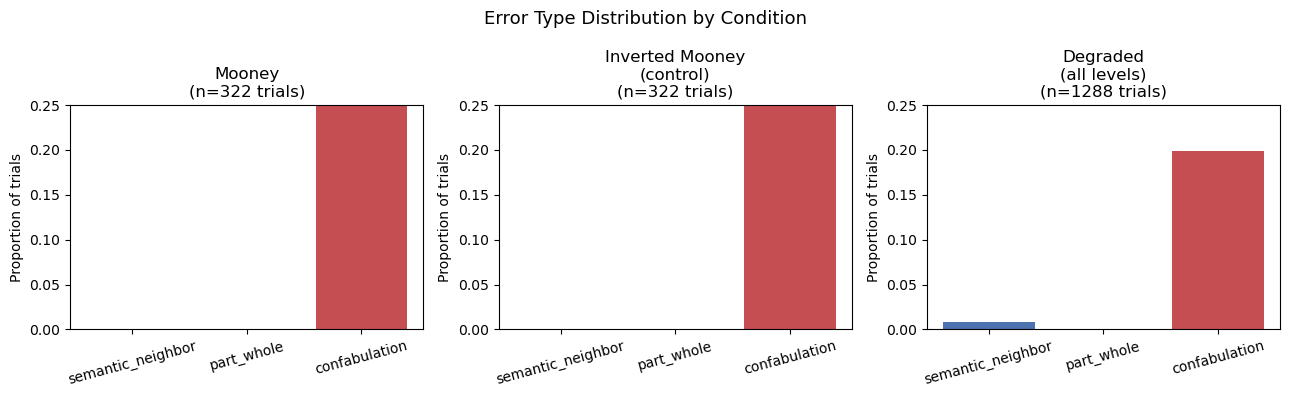

In [9]:
# Semantic neighbor sets — objects that are easily confused
SEMANTIC_NEIGHBORS = {
    "seal":          ["walrus", "sea lion", "otter"],
    "toe":           ["finger", "thumb"],
    "thumb":         ["finger", "toe"],
    "mouse":         ["rat", "hamster", "gerbil"],
    "lettuce":       ["cabbage", "spinach", "salad"],
    "lips":          ["mouth"],
    "jacket":        ["coat", "shirt", "blazer"],
    "swan":          ["goose", "duck", "bird"],
    "sheep":         ["goat", "lamb", "cow"],
    "ring":          ["bracelet", "watch", "pocket watch"],
    "pencil":        ["pen", "marker", "crayon"],
    "paintbrush":    ["brush", "broom"],
    "tennis racket": ["badminton racket", "racket"],
    "thimble":       ["cup", "toaster"],
}

# Body part / part-whole confusion set
PART_WHOLE = {
    "nose":  ["face", "head"],
    "thumb": ["finger", "hand"],
    "toe":   ["finger", "foot"],
    "lips":  ["face", "mouth"],
    "hair":  ["head"],
    "leg":   ["body"],
}


def classify_error(response, true_label):
    """
    For an incorrect trial, classify the error type.
    Returns: 'semantic_neighbor', 'part_whole', or 'confabulation'
    """
    resp = response.lower().strip()
    label = true_label.lower().replace("_", " ").strip()

    if label in PART_WHOLE:
        for pw in PART_WHOLE[label]:
            if pw in resp:
                return "part_whole"

    if label in SEMANTIC_NEIGHBORS:
        for neighbor in SEMANTIC_NEIGHBORS[label]:
            if neighbor in resp:
                return "semantic_neighbor"

    return "confabulation"


results_df = pd.read_csv("results.csv")

errors = results_df[results_df["correct"] == False].copy()
errors["error_type"] = errors.apply(
    lambda r: classify_error(r["response"], r["label"]), axis=1
)

print("Error counts by condition and type:")
print(errors.groupby(["condition", "error_type"]).size().unstack(fill_value=0))
print()
print("All errors with type:")
print(errors[["condition", "label", "response", "error_type"]].to_string())

# Plot: 3 panels — mooney, mooney_inv, and degraded (aggregated across levels)
# Aggregating degraded_25/50/75 gives a stable error-type estimate across all degradation
errors["condition_group"] = errors["condition"].apply(
    lambda c: "degraded (all levels)" if c.startswith("degraded") else c
)

results_df["condition_group"] = results_df["condition"].apply(
    lambda c: "degraded (all levels)" if c.startswith("degraded") else c
)

plot_conditions = ["mooney", "mooney_inv", "degraded (all levels)"]
condition_labels = ["Mooney", "Inverted Mooney\n(control)", "Degraded\n(all levels)"]
error_types = ["semantic_neighbor", "part_whole", "confabulation"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, cond, cond_label in zip(axes, plot_conditions, condition_labels):
    subset_errors = errors[errors["condition_group"] == cond]
    total = len(results_df[results_df["condition_group"] == cond])
    counts = [len(subset_errors[subset_errors["error_type"] == t]) for t in error_types]
    ax.bar(error_types, [c / total for c in counts], color=colors)
    ax.set_title(f"{cond_label}\n(n={total} trials)")
    ax.set_ylabel("Proportion of trials")
    ax.set_ylim(0, 0.25)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Error Type Distribution by Condition", fontsize=13)
plt.tight_layout()
plt.savefig("error_type_analysis.png", dpi=150)
plt.show()
